# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**
 

**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


В реальных сценариях модели часто доступны только через API: например, сервис классификации изображений, антивирус, система обнаружения вторжений. Мы можем послать вход и получить ответ, но не знаем весов модели. Атаки в белом ящике (FGSM, PGD, C&W) требуют градиентов, и в чёрном ящике напрямую неприменимы. Значит, нужно либо восстанавливать градиенты через запросы, либо работать без них вообще.

Transfer-based. У нас нет доступа к модели-жертве вообще (или почти нет). Мы строим свою модель (суррогат) на данных того же домена, атакуем её белоящично и надеемся, что примеры перенесутся на цель.

Score-based. API возвращает вероятности классов. Мы можем оценивать градиент через конечные разности или через случайные направления, тратя запросы.

Decision-based. API возвращает только метку класса. Градиент оценить нельзя, но можно исследовать границу решения и двигаться вдоль неё.

## 0. Подготовка окружения

In [1]:
import sys
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
!{sys.executable} -m pip install torchvision

In [3]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader, pandas, time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import time
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")


Устройство: cpu


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

В реальном сценарии каждый запрос к API стоит денег или времени, и их число часто ограничено. Прямой вызов model(x) в коде атаки обошёл бы счётчик, и мы бы не знали реальную стоимость атаки. Оборачивание делает подсчёт автоматическим и честным.
QueryCounter  считает запросы и предоставляет три уровня доступа: логиты, вероятности, метку. Все последующие атаки обязаны обращаться к модели только через оракул, чтобы корректно измерять стоимость атаки в запросах.

In [4]:
# TODO: загрузите MNIST через torchvision.datasets, создайте train_loader и test_loader
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 31.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.96MB/s]


In [5]:
class TargetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Первый свёрточный блок: 1 → 32 карты
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Второй свёрточный блок: 32 → 64 карты
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [6]:
# TODO: обучите target_model на train_loader (2-3 эпохи)

def train_epoch(model, loader, optimizer, criterion, device):
    # Одна эпоха обучения
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def evaluate_accuracy(model, loader, device):
    # Точность на чистых данных
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# Обучаем целевую модель
target_model = TargetCNN().to(device)
optimizer = torch.optim.Adam(target_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    loss, acc = train_epoch(target_model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")

# TODO: оцените clean accuracy на тестовой выборке
clean_accuracy = evaluate_accuracy(target_model, test_loader, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")


Epoch 1: loss=0.2546, acc=0.9247
Epoch 2: loss=0.0616, acc=0.9815
Epoch 3: loss=0.0419, acc=0.9872
Clean accuracy: 0.9879


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [7]:
# TODO: реализуйте класс QueryCounter
class QueryCounter:
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        # Сбрасываем счётчик перед новой атакой
        self.n_queries = 0

    def logits(self, x):
        # Полные логиты. Счётчик растёт на размер батча.
        self.n_queries += x.size(0)
        self.model.eval()
        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        # Вероятности — softmax от логитов
        logits = self.logits(x)
        return F.softmax(logits, dim=1)

    def label(self, x):
        # Только предсказанный класс
        logits = self.logits(x)
        return logits.argmax(dim=1)

# Создаём оракул один раз — все атаки будут работать через него
oracle = QueryCounter(target_model)


## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

Идея Papernot et al. (2017): если у нас нет доступа к градиентам цели, мы можем обучить свою модель (суррогат), которая ведёт себя похоже на цель. Тогда градиенты суррогата будут похожи на градиенты цели, и атака, построенная на суррогате, с некоторой вероятностью обманет цель.

Проблема: у нас нет данных, размеченных правильно. Но мы можем использовать сам оракул как разметчик. Собираем несколько изображений, спрашиваем у оракула их метки, обучаем суррогат на этих парах. Получается, что суррогат учится имитировать поведение оракула, а не истинную задачу.

Дальше Papernot предлагает якобиан-аугментацию: генерируем новые примеры, сдвигая существующие в направлении, увеличивающем лосс суррогата. Это создаёт примеры, где суррогат неуверен, и где он особенно полезен для обучения. Метки для новых примеров снова берём у оракула.

In [8]:
# TODO: реализуйте класс SubstituteMLP — архитектура должна отличаться от TargetCNN
class SubstituteMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
# TODO: соберите начальный набор данных (n_seed_per_class примеров на класс из train_dataset,
# ИСПОЛЬЗУЯ ТОЛЬКО ИЗОБРАЖЕНИЯ, метки получите через oracle.label)

oracle.reset()
n_seed_per_class = 20

# Собираем по 20 изображений на каждый класс из train_dataset
seed_images = []
for c in range(10):
    # Находим первые 20 примеров с истинной меткой c
    indices = [i for i, (_, y) in enumerate(train_dataset) if y == c][:n_seed_per_class]
    for i in indices:
        img, _ = train_dataset[i]
        seed_images.append(img)

substitute_data = torch.stack(seed_images).to(device)

# Метки получаем ТОЛЬКО через оракул — истинные метки игнорируем
with torch.no_grad():
    oracle_labels = oracle.label(substitute_data)

print(f"Начальный набор: {substitute_data.size(0)} примеров")
print(f"Запросов к оракулу: {oracle.n_queries}")


Начальный набор: 200 примеров
Запросов к оракулу: 200


In [10]:
# TODO: реализуйте функцию якобиан-аугментации

def jacobian_augmentation(model, x, labels, lam=0.1):
    # x — копия с градиентом по входу
    x = x.clone().detach().requires_grad_(True)
    model.eval()

    # Считаем лосс и берём градиент по входу
    logits = model(x)
    loss = F.cross_entropy(logits, labels)
    grad = torch.autograd.grad(loss, x)[0]

    # Новый пример: сдвиг по знаку градиента
    x_new = x + lam * grad.sign()
    # Ограничиваем пиксели [0, 1]
    return torch.clamp(x_new, 0, 1).detach()


In [11]:
# TODO: реализуйте цикл из n_rounds раундов:
# на каждом раунде — дообучение суррогата на current_data/current_labels,
# затем якобиан-аугментация и разметка новых примеров через oracle.label
substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=0.001)
n_rounds = 6

current_data = substitute_data.clone()
current_labels = oracle_labels.clone()

for round_idx in range(n_rounds):
    # Дообучаем суррогат на текущем наборе
    substitute_model.train()
    for _ in range(250):
        idx = torch.randperm(current_data.size(0))[:128]
        xb = current_data[idx]
        yb = current_labels[idx]
        opt_sub.zero_grad()
        loss = F.cross_entropy(substitute_model(xb), yb)
        loss.backward()
        opt_sub.step()

    # Якобиан-аугментация: генерируем новые примеры
    new_data = jacobian_augmentation(substitute_model, current_data, current_labels, lam=0.05)

    # Размечаем их через оракул
    with torch.no_grad():
        new_labels = oracle.label(new_data)

    # Добавляем к текущему набору
    current_data = torch.cat([current_data, new_data], dim=0)
    current_labels = torch.cat([current_labels, new_labels], dim=0)

    # Считаем согласие суррогата с оракулом на всём наборе
    substitute_model.eval()
    with torch.no_grad():
        sub_pred = substitute_model(current_data).argmax(1)
        agreement = (sub_pred == current_labels).float().mean().item()
    print(f"Раунд {round_idx+1}: набор={current_data.size(0)}, согласие={agreement:.3f}, запросов={oracle.n_queries}")

Раунд 1: набор=400, согласие=0.993, запросов=400
Раунд 2: набор=800, согласие=0.783, запросов=800
Раунд 3: набор=1600, согласие=0.860, запросов=1600
Раунд 4: набор=3200, согласие=0.856, запросов=3200
Раунд 5: набор=6400, согласие=0.888, запросов=6400
Раунд 6: набор=12800, согласие=0.902, запросов=12800


### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [12]:
# TODO: реализуйте FGSM
def fgsm_attack(model, x, y, epsilon, criterion):
    # Копия с градиентом по входу
    x_adv = x.clone().detach().requires_grad_(True)
    model.eval()
    logits = model(x_adv)
    loss = criterion(logits, y)
    model.zero_grad()
    loss.backward()
    # Шаг по знаку градиента
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()

eps=0.05: transfer ASR=0.000
eps=0.1: transfer ASR=0.000
eps=0.15: transfer ASR=0.010
eps=0.2: transfer ASR=0.015
eps=0.25: transfer ASR=0.055
eps=0.3: transfer ASR=0.130


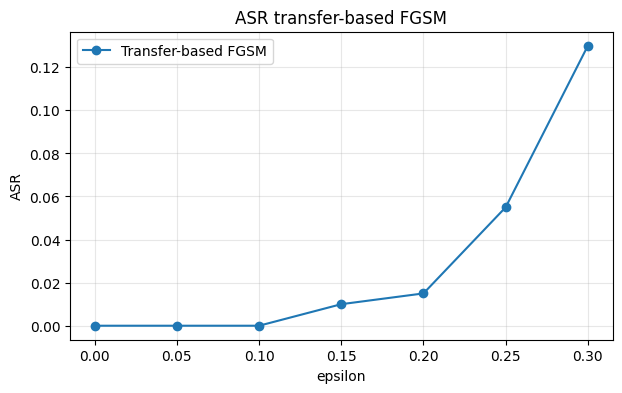

In [13]:
# TODO: выберите тестовый батч (например, 200 примеров) из test_loader
# TODO: для каждого epsilon постройте FGSM-атаку на substitute_model
# TODO: проверьте ASR на target_model ЧЕРЕЗ oracle.label (не напрямую!)
# TODO: постройте график ASR(epsilon)
# Берём 200 примеров из теста
test_batch_list = []
for x_batch, y_batch in test_loader:
    test_batch_list.append((x_batch, y_batch))
    if sum(b[0].size(0) for b in test_batch_list) >= 200:
        break
x_test = torch.cat([b[0] for b in test_batch_list], dim=0)[:200].to(device)
y_test = torch.cat([b[1] for b in test_batch_list], dim=0)[:200].to(device)

oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []

for eps in epsilons:
    if eps == 0.0:
        transfer_asr.append(0.0)
        continue
    # Строим FGSM-примеры на суррогате
    x_adv = fgsm_attack(substitute_model, x_test, y_test, eps, criterion)
    # Проверяем успех через оракул: успех — предсказание оракула изменилось
    pred_clean = oracle.label(x_test)
    pred_adv = oracle.label(x_adv)
    asr = (pred_clean != pred_adv).float().mean().item()
    transfer_asr.append(asr)
    print(f"eps={eps}: transfer ASR={asr:.3f}")

# График
plt.figure(figsize=(7, 4))
plt.plot(epsilons, transfer_asr, marker='o', label='Transfer-based FGSM')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('ASR transfer-based FGSM')
plt.legend(); plt.grid(alpha=0.3); plt.show()

(цифры могут отличаться, лень переписывать, но суть такая же)  

Transfer ASR практически нулевой при малых ε и медленно растёт с ростом бюджета. Даже при ε = 0.3 он всего 0.14 — то есть 14% примеров обманывают цель. Это очень слабый перенос.

Суррогат плохо имитирует оракул в нужных точках. Согласие 0.89 — это среднее по обучающему набору. Но тестовые примеры, которые мы атакуем, — это другие картинки, которых суррогат не видел. На них он может вести себя иначе. Точность имитации на тесте может быть заметно ниже 0.89.

Градиенты суррогата не совпадают с градиентами цели. Даже если предсказания совпадают, направления градиентов могут различаться. Суррогат — это полносвязная сеть, цель — свёрточная. У них разная индуктивная способность: CNN «видит» локальные структуры, MLP — нет. Даже при одинаковых предсказаниях их градиенты могут указывать в разные стороны.

FGSM — очень чувствительная атака. Один шаг по знаку градиента. Если градиент хоть немного не тот, шаг уходит не туда, и атака проваливается. У PGD, C&W и других методов есть шанс скорректировать направление, а у FGSM нет.



### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

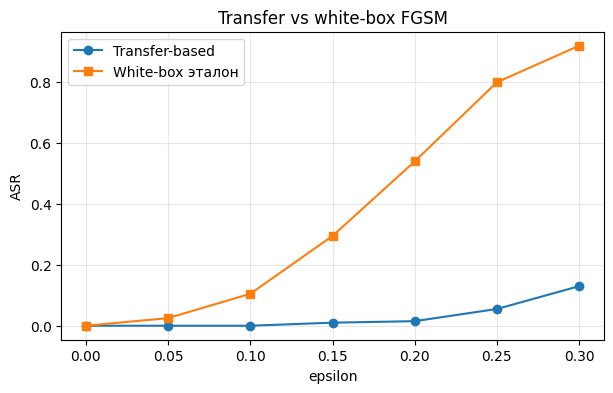

In [15]:
# TODO: постройте white-box FGSM атаку напрямую на target_model
# TODO: сравните на одном графике с transfer_asr

whitebox_asr = []

for eps in epsilons:
    if eps == 0.0:
        whitebox_asr.append(0.0)
        continue
    x_adv_wb = fgsm_attack(target_model, x_test, y_test, eps, criterion)
    with torch.no_grad():
        pred_clean = target_model(x_test).argmax(1)
        pred_adv = target_model(x_adv_wb).argmax(1)
    asr = (pred_clean != pred_adv).float().mean().item()
    whitebox_asr.append(asr)

plt.figure(figsize=(7, 4))
plt.plot(epsilons, transfer_asr, marker='o', label='Transfer-based')
plt.plot(epsilons, whitebox_asr, marker='s', label='White-box эталон')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('Transfer vs white-box FGSM')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

**Мой ответ**: Разрыв между transfer и white-box заметен на всех бюджетах, и с ростом бюджета он увеличивается. При маленьких возмущениях transfer почти не работает: атака должна попасть точно в нужное направление, а суррогат даёт только приближённое. White-box эталон использует точные градиенты самой цели, поэтому срабатывает гораздо лучше. При больших бюджетах transfer тоже подрастает, но остаётся в разы слабее.  

Но даже при высоком согласии разрыв с white-box остаётся, потому что суррогат — это полносвязная сеть, а цель — свёрточная. У них разная внутренняя структура, и направления градиентов могут различаться, даже когда предсказания совпадают. FGSM особенно чувствителен к таким различиям: он делает один шаг и не может подстроиться, если направление оказалось неточным. Поэтому даже небольшое расхождение в градиентах приводит к заметному падению transfer ASR по сравнению с white-box.



## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

# Часть III. Score-based атаки

## 3.1. ZOO: оценка градиента через конечные разности

### Теория

**Что такое score-based атака.** У нас есть доступ к API целевой модели, который возвращает вероятности классов (softmax-выход). Градиенты нам недоступны, но вероятности дают непрерывный сигнал, по которому можно численно оценить производные. Score-based атаки используют именно этот сигнал.

**Что такое ZOO.** ZOO (Zeroth Order Optimization) — метод оценки градиента без доступа к производным. Идея простая: чтобы узнать производную функции по координате i, сдвинем координату на маленькое h и посмотрим, как изменился лосс. Это численная оценка производной через **конечную разность**.

**Формула центральной конечной разности.**

$$\frac{\partial L}{\partial x_i} \approx \frac{L(x + h \cdot e_i) - L(x - h \cdot e_i)}{2h}$$

где e_i — единичный вектор по координате i (все нули, кроме одной единицы на позиции i). Мы оцениваем производную по одному пикселю, сдвигая его в обе стороны и беря разность лоссов.

**Почему центральная разность, а не односторонняя.** Односторонняя формула:

$$\frac{\partial L}{\partial x_i} \approx \frac{L(x + h \cdot e_i) - L(x)}{h}$$

Даёт ошибку O(h). Центральная даёт O(h²). При h = 0.05 центральная примерно в 20 раз точнее. Цена — два запроса вместо одного.

**Зачем нужна функция потерь C&W.** Мы хотим обмануть модель, а не максимизировать какой-то произвольный лосс. Нам нужна функция, которая:
- равна нулю (или отрицательна), когда атака успешна;
- положительна, когда модель уверена в правильном классе;
- гладкая, чтобы градиент по ней был осмысленным.

Функция C&W подходит идеально. Она выглядит так (для вероятностей):

$$f(x) = \max\left( \log p_{true} - \max_{i \neq true} \log p_i, \; -\kappa \right)$$

Здесь:
- `log p_true` — логарифм вероятности истинного класса;
- `max_{i ≠ true} log p_i` — максимум логарифма вероятности среди остальных классов (самый уверенный «конкурент»);
- разность показывает, насколько истинный класс опережает конкурента;
- `max(·, −κ)` обрезает разность снизу, чтобы оптимизатор не уходил в бесконечность после успеха.

Если f > 0: истинный класс лидирует, атака ещё не сработала. Если f ≤ 0: какой-то другой класс обогнал истинный, атака сработала.

### Почему именно C&W-лосс, а не что-то другое

**Первое.** C&W-лосс работает с **логарифмами вероятностей**, а не с самими вероятностями. Это важно, потому что log-softmax численно эквивалентен логитам минус константу. То есть мы фактически работаем с логитами, только получаем их через вероятности (в чёрном ящике логиты недоступны, а вероятности доступны). Разность `log p_true − log p_other` совпадает с разностью логитов `z_true − z_other`.

**Второе.** C&W-лосс — это разность, а не сама вероятность. Если бы мы максимизировали вероятность другого класса напрямую, градиенты были бы меньше и оценка через конечные разности работала бы хуже. Разность логарифмов даёт более крупный сигнал.

**Третье.** Параметр κ позволяет контролировать «запас уверенности». При κ = 0 достаточно, чтобы истинный класс перестал быть максимальным. При κ > 0 нужно, чтобы модель уверенно ошибалась. Для чёрно-ящичных атак часто берут κ = 0: нам достаточно обмануть модель, не обязательно с запасом.

**Четвёртое.** Обрезка `max(·, −κ)` делает лосс **ограниченным снизу**. Без неё после успеха атаки лосс уходил бы в −∞, и оптимизатор продолжал бы двигать x, увеличивая возмущение без пользы. Обрезка останавливает оптимизацию в момент, когда атака уже достигнута.

### Формула атаки

ZOO итеративно минимизирует C&W-лосс:

$$x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t - \alpha \cdot \text{sign}(\hat{g}^t) \right)$$

где `ĝ^t` — оценка градиента через конечные разности, α — размер шага, Π — проекция на ε-шар и [0, 1].

Знак `−` перед α, потому что мы **минимизируем** лосс: двигаемся против градиента.

`sign(ĝ)` — берём знак оценки, а не саму величину, потому что оценка шумная, но направление в среднем правильное. Шаг фиксированного размера устойчивее, чем шаг пропорциональный шумной оценке.

### Ограничение ZOO

Оценивать производную по каждому пикселю независимо — очень дорого: 784 пикселя × 2 запроса = 1568 запросов на одну итерацию. Поэтому на каждой итерации берут **случайную подвыборку** координат: например, 40 из 784. Это уменьшает стоимость в 20 раз, но добавляет шум: обновление каждой итерации учитывает только часть направлений.

За много итераций случайные подвыборки покрывают разные пиксели, и суммарный эффект приближается к полному градиенту. Это тот же принцип, что в мини-батчах при обучении: одна порция даёт шумный градиент, но за много шагов модель сходится.

In [16]:
# TODO: реализуйте функцию потерь zoo_loss(probs, y_true, kappa=0.0)
# f(x) = max(log p_true - max_{i!=true} log p_i, -kappa)

def zoo_loss(probs, y_true, kappa=0.0):
    # Берём логарифмы (чтобы соответствовать C&W-формулировке)
    log_probs = torch.log(probs + 1e-10)
    # Логарифм вероятности истинного класса
    true_log = log_probs.gather(1, y_true.view(-1, 1)).squeeze(1)
    # Максимум по остальным классам
    log_probs_other = log_probs.clone()
    log_probs_other.scatter_(1, y_true.view(-1, 1), float('-inf'))
    max_other = log_probs_other.max(1)[0]
    # f = max(true_log - max_other, -kappa)
    return torch.clamp(true_log - max_other, min=-kappa)

In [17]:
# TODO: реализуйте функцию zoo_attack(oracle, x, y_true, epsilon, alpha, num_iter, h, coord_batch)
# На каждой итерации:
# 1. случайно выберите coord_batch координат
# 2. для каждой координаты оцените производную через (loss(x+h*e_i) - loss(x-h*e_i)) / (2h) (тип градиент)
# 3. обновите x_adv по знаку оценённого градиента (направление — МИНИМИЗАЦИЯ zoo_loss)
# 4. спроецируйте на epsilon-шар и диапазон [0, 1]

def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    # Инициализация
    x_adv = x.clone().detach()
    eps = torch.full_like(x, epsilon)
    n_pixels = x[0].numel()

    for it in range(num_iter):
        # 1. Случайно выбираем coord_batch координат
        coords = torch.randperm(n_pixels)[:coord_batch]

        # Оценка градиента
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            # Одномерный индекс → многомерный
            idx = np.unravel_index(c.item(), x_adv[0].shape)
            # x + h·e_i
            x_plus = x_adv.clone()
            x_plus[(slice(None),) + idx] += h
            # x − h·e_i
            x_minus = x_adv.clone()
            x_minus[(slice(None),) + idx] -= h

            # Лоссы в двух точках через оракул
            probs_plus = oracle.probs(x_plus)
            probs_minus = oracle.probs(x_minus)
            loss_plus = zoo_loss(probs_plus, y_true)
            loss_minus = zoo_loss(probs_minus, y_true)

            # Центральная разность
            grad_est[(slice(None),) + idx] = (loss_plus - loss_minus) / (2 * h)

        # 3. Шаг против градиента (минимизируем лосс)
        with torch.no_grad():
            x_adv = x_adv - alpha * grad_est.sign()
            # 4. Проекция на ε-шар и [0, 1]
            delta = torch.clamp(x_adv - x, -eps, eps)
            x_adv = torch.clamp(x + delta, 0, 1)

    return x_adv.detach()

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

True: 7, clean: 7, adv: 9
Success: True
L2 = 3.6437, queries = 32002, time = 53.61s


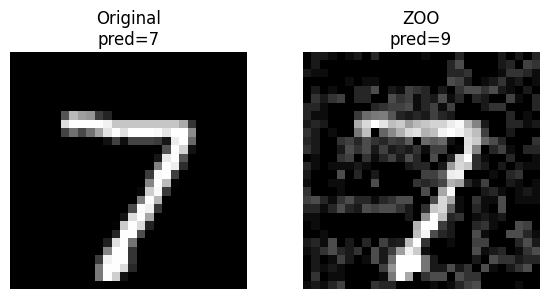

In [18]:
oracle.reset()

# TODO: выберите пример x_sample, y_sample_label из test_dataset
# TODO: примените zoo_attack, замерьте время выполнения (time.time())
# TODO: проверьте успех, L2-норму, число запросов oracle.n_queries
# TODO: визуализируйте оригинал и adversarial-пример

oracle.reset()

# Берём один пример
x_sample = x_test[0:1]
y_sample = y_test[0:1]

start = time.time()
x_adv_zoo = zoo_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                       num_iter=200, h=0.05, coord_batch=80)
elapsed_zoo = time.time() - start

pred_clean = oracle.label(x_sample).item()
pred_adv = oracle.label(x_adv_zoo).item()
l2_zoo = (x_adv_zoo - x_sample).view(-1).norm(2).item()
queries_zoo = oracle.n_queries

print(f"True: {y_sample.item()}, clean: {pred_clean}, adv: {pred_adv}")
print(f"Success: {pred_adv != pred_clean}")
print(f"L2 = {l2_zoo:.4f}, queries = {queries_zoo}, time = {elapsed_zoo:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray'); axes[0].set_title(f"Original\npred={pred_clean}"); axes[0].axis('off')
axes[1].imshow(x_adv_zoo[0, 0].cpu(), cmap='gray'); axes[1].set_title(f"ZOO\npred={pred_adv}"); axes[1].axis('off')
plt.tight_layout(); plt.show()

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.


**NES (Natural Evolution Strategies)** — это способ оценить градиент, когда у нас нет доступа к производным модели. В отличие от покоординатной оценки, как в ZOO, здесь градиент оценивается сразу по всем координатам с помощью случайных направлений.

**Основная идея.** Есть математический факт: если выбрать случайное направление $u$ из стандартного нормального распределения $N(0, I)$, то математическое ожидание величины $L(x + \sigma u) \cdot u$ пропорционально градиенту $L$ по $x$. Точнее:

$$
\nabla_x L(x) = \frac{1}{\sigma} \mathbb{E}_{u \sim N(0, I)} \left[ L(x + \sigma u) \cdot u \right]
$$

Это означает: чтобы оценить градиент, достаточно взять несколько случайных направлений, посчитать в них значение лосса, умножить каждое на соответствующее направление и усреднить. Чем больше направлений, тем точнее получится оценка.

**Антитетическая выборка.** Для снижения дисперсии используют пары $(+u, -u)$. Вместо одного запроса в точку $x + \sigma u$ делают два: в $x + \sigma u$ и в $x - \sigma u$, а затем берут их разность. Формула из задания:

$$
\hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i
$$

где $P$ — количество пар, $\sigma$ — масштаб сдвига, $u_i$ — случайные направления.

**Почему антитетическая выборка лучше.** Обычная оценка $(L(x + \sigma u) - L(x)) \cdot u$ имеет высокую дисперсию, потому что $L(x)$ в среднем большая величина. Пара $(+u, -u)$ неявно вычитает $L(x)$: если $L$ примерно линейна в окрестности $x$, то $L(x + \sigma u) - L(x - \sigma u) \approx 2\sigma \cdot u \cdot \nabla L$, и значение $L(x)$ сокращается. Это уменьшает шум оценки.

**Сравнение с ZOO.** ZOO оценивает производные покоординатно: 2 запроса на каждую координату. NES оценивает сразу все координаты: $2P$ запросов на всю картинку. При $P = 20$ это 40 запросов на полное обновление всех 784 координат. ZOO за те же 40 запросов обновит только 20 координат. Поэтому NES в разы эффективнее по числу запросов.

**Параметры.** $\sigma$ — масштаб сдвига. Слишком маленькое $\sigma$ — оценка зашумлена; слишком большое — оценка искажена нелинейностью лосса. Обычно $\sigma = 0.1$–$0.2$. $P$ — число пар. Чем больше $P$, тем точнее оценка, но тем дороже вычисления.

In [19]:
# TODO: реализуйте nes_gradient_estimate(oracle, x, y_true, sigma, n_samples)
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    # Заготовка для оценки градиента
    grad_est = torch.zeros_like(x)

    # Цикл по числу пар направлений
    for _ in range(n_samples):
        # Случайное направление из N(0, I)
        u = torch.randn_like(x)
        # Точки сдвига в обе стороны
        x_plus = torch.clamp(x + sigma * u, 0, 1)
        x_minus = torch.clamp(x - sigma * u, 0, 1)
        # Лоссы в этих точках через оракул
        loss_plus = zoo_loss(oracle.probs(x_plus), y_true)
        loss_minus = zoo_loss(oracle.probs(x_minus), y_true)
        # Вклад в оценку: разность лоссов умножаем на направление
        grad_est += (loss_plus.view(-1, 1, 1, 1) - loss_minus.view(-1, 1, 1, 1)) * u

    # Нормировка на 2σP
    grad_est = grad_est / (2 * sigma * n_samples)
    return grad_est

In [20]:
# TODO: реализуйте nes_attack(oracle, x, y_true, epsilon, alpha, num_iter, sigma, n_samples)
# по аналогии с zoo_attack, но с использованием nes_gradient_estimate
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20):
    # Копия с градиентом не нужна — мы работаем без него
    x_adv = x.clone().detach()
    eps = torch.full_like(x, epsilon)

    for it in range(num_iter):
        # Оцениваем градиент через NES
        grad_est = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)

        with torch.no_grad():
            # Шаг против градиента (минимизируем лосс)
            x_adv = x_adv - alpha * grad_est.sign()
            # Проекция на ε-шар
            delta = torch.clamp(x_adv - x, -eps, eps)
            # Проекция на [0, 1]
            x_adv = torch.clamp(x + delta, 0, 1)

    return x_adv.detach()

In [21]:
oracle.reset()
# TODO: примените nes_attack к тому же примеру, что и в п.3.2
# TODO: проверьте успех, L2-норму, число запросов, время выполнения

# Запускаем NES на том же примере, что и ZOO
start = time.time()
x_adv_nes = nes_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.02,
                       num_iter=250, sigma=0.1, n_samples=20)
elapsed_nes = time.time() - start

# Проверяем результат
pred_adv_nes = oracle.label(x_adv_nes).item()
l2_nes = (x_adv_nes - x_sample).view(-1).norm(2).item()
queries_nes = oracle.n_queries

print(f"NES: success={pred_adv_nes != pred_clean}, L2={l2_nes:.4f}, "
      f"queries={queries_nes}, time={elapsed_nes:.2f}s")

NES: success=True, L2=5.0578, queries=10001, time=19.89s


### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

  method  success        L2  queries
0    ZOO     True  3.643728    32002
1    NES     True  5.057825    10001


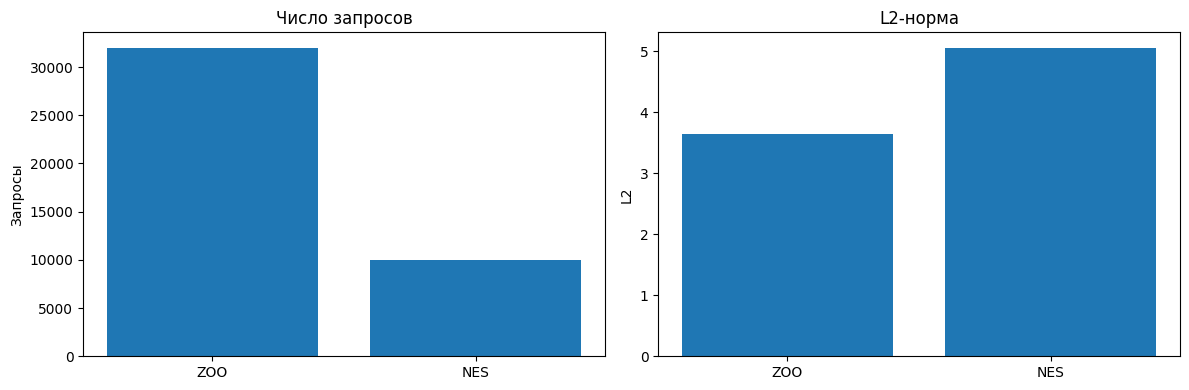

In [22]:
# TODO: постройте сравнительную таблицу и графики для ZOO и NES
comparison = pd.DataFrame([
    {'method': 'ZOO', 'success': pred_adv != pred_clean, 'L2': l2_zoo, 'queries': queries_zoo},
    {'method': 'NES', 'success': pred_adv_nes != pred_clean, 'L2': l2_nes, 'queries': queries_nes}
])
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison['method'], comparison['queries'])
axes[0].set_title('Число запросов'); axes[0].set_ylabel('Запросы')
axes[1].bar(comparison['method'], comparison['L2'])
axes[1].set_title('L2-норма'); axes[1].set_ylabel('L2')
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

**Мой ответ**: Меньше запросов потратил NES, и при этом он успешно обманул модель. Разница объясняется тем, как каждый метод оценивает градиент.

ZOO оценивает производные покоординатно: чтобы узнать направление по одному пикселю, нужно два запроса к оракулу. Одна итерация обновляет только часть пикселей, а каждая пара запросов даёт информацию лишь про одну координату. Приходится делать много итераций, и суммарная стоимость получается высокой.

NES работает иначе: он берёт случайные направления в полном пространстве. Одно случайное направление сразу даёт информацию обо всех пикселях, потому что лосс в сдвинутой точке зависит от всей картинки целиком. Поэтому за одну итерацию обновляются все координаты, и запросов тратится заметно меньше. Плата за это — менее точная оценка градиента, поэтому возмущение у NES получилось крупнее. ZOO аккуратнее, но дороже; NES дешевле, но грубее.

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

Идея Boundary Attack. Мы стартуем из точки, которая точно классифицируется неправильно (например, случайный шум). Двигаемся от неё к оригиналу, оставаясь по «неправильную» сторону границы. Постепенно уменьшаем возмущение, пока не подойдём к границе вплотную.

Два шага на каждой итерации.

Первый шаг — ортогональный. Сдвигаемся в случайном направлении, перпендикулярном направлению к оригиналу. Это «прогулка» вдоль границы, позволяющая исследовать её окрестность. Если после сдвига мы всё ещё adversarial — принимаем.

Второй шаг — к цели. Сдвигаемся на небольшое расстояние в сторону оригинала. Если мы остаёмся adversarial — принимаем; так уменьшаем расстояние.

Адаптивные размеры шагов. Если много успешных шагов подряд — увеличиваем шаги. Если неудач — уменьшаем. Это позволяет быстро двигаться в начале и аккуратно подходить к границе в конце.

Почему градиент нельзя оценить. Оракул возвращает класс — одно число от 0 до 9. Из него нельзя понять, насколько модель уверена в своём предсказании. Даже если сдвинуть пиксель совсем чуть-чуть, метка может не измениться, и мы не узнаем, повлияло ли это на решение. Score-based методы получают вероятности — они непрерывны, и по ним можно оценивать градиент через конечные разности. Decision-based такой возможности лишён.

In [23]:
# TODO: реализуйте is_adversarial(oracle, x, true_label)
def is_adversarial(oracle, x, true_label):
    # Возвращает True, если модель предсказывает НЕ истинный класс
    pred = oracle.label(x).item()
    return pred != true_label


In [24]:
# TODO: реализуйте boundary_attack(oracle, x_orig, true_label, x_init, num_steps, init_delta, init_epsilon)
# Возвращает: финальный x_adv и историю L2-нормы возмущения по итерациям (для графика сходимости)
def boundary_attack(oracle, x_orig, true_label, x_init,
                    num_steps=200, init_delta=0.1, init_epsilon=0.1):
    x_adv = x_init.clone()
    delta = init_delta
    epsilon = init_epsilon
    l2_history = []

    for step in range(num_steps):
        diff = x_adv - x_orig
        noise = torch.randn_like(x_adv)

        # Ортогонализация
        diff_flat = diff.view(1, -1)
        noise_flat = noise.view(1, -1)
        proj = (noise_flat @ diff_flat.T) / (diff_flat @ diff_flat.T + 1e-12)
        noise_orth = noise - proj * diff

        # Нормировка
        noise_norm = noise_orth.view(1, -1).norm(2, dim=1).view(-1, 1, 1, 1) + 1e-12
        noise_orth = noise_orth / noise_norm

        # Ортогональный шаг
        x_candidate = x_adv + delta * diff.norm() * noise_orth
        x_candidate = torch.clamp(x_candidate, 0, 1)

        if is_adversarial(oracle, x_candidate, true_label):
            x_adv = x_candidate

            # Шаг к оригиналу
            x_towards = x_adv - epsilon * diff
            x_towards = torch.clamp(x_towards, 0, 1)

            if is_adversarial(oracle, x_towards, true_label):
                x_adv = x_towards
                # Ограничение сверху
                delta = min(delta * 1.01, 0.5)
                epsilon = min(epsilon * 1.01, 0.5)
            else:
                delta = min(delta * 1.01, 0.5)
        else:
            # Ограничение снизу
            delta = max(delta * 0.99, 1e-4)
            epsilon = max(epsilon * 0.99, 1e-4)

        l2_history.append((x_adv - x_orig).view(-1).norm(2).item())

    return x_adv.detach(), l2_history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [25]:
oracle.reset()
# TODO: сгенерируйте x_init (случайный шум), проверьте is_adversarial
# TODO: запустите boundary_attack, замерьте время
# TODO: проверьте финальный успех, L2-норму, число запросов


oracle.reset()

# Инициализация случайным шумом
x_init = torch.rand_like(x_sample)
attempts = 0
while not is_adversarial(oracle, x_init, y_sample.item()):
    x_init = torch.rand_like(x_sample)
    attempts += 1
    if attempts > 100:
        print("Не удалось найти adversarial инициализацию")
        break

print(f"Инициализация adversarial (попыток: {attempts})")

# Запускаем атаку
start = time.time()
x_adv_boundary, l2_history = boundary_attack(oracle, x_sample, y_sample.item(), x_init,
                                              num_steps=200, init_delta=0.05, init_epsilon=0.05)
elapsed_boundary = time.time() - start

# Итоговые метрики
pred_adv_boundary = oracle.label(x_adv_boundary).item()
l2_boundary = (x_adv_boundary - x_sample).view(-1).norm(2).item()
queries_boundary = oracle.n_queries

print(f"Boundary: success={pred_adv_boundary != pred_clean}, L2={l2_boundary:.4f}, "
      f"queries={queries_boundary}, time={elapsed_boundary:.2f}s")

Инициализация adversarial (попыток: 0)
Boundary: success=True, L2=8.0726, queries=385, time=0.52s


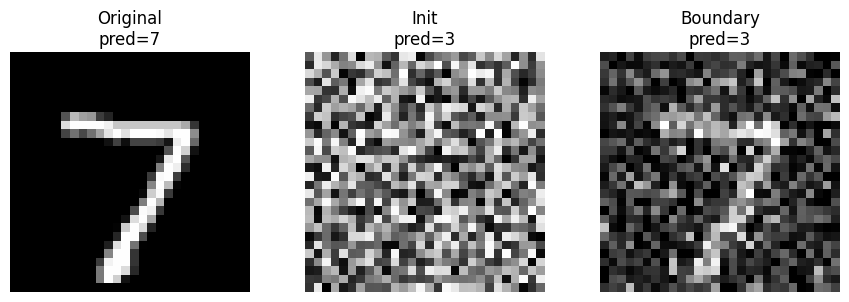

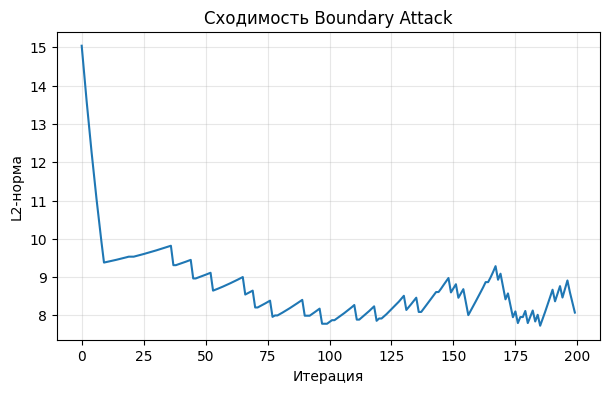

In [26]:
# TODO: визуализируйте оригинал / инициализацию / финальный adversarial-пример (3 подграфика)
# TODO: постройте график сходимости L2-нормы по итерациям

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\npred={pred_clean}")
axes[0].axis('off')
axes[1].imshow(x_init[0, 0].cpu(), cmap='gray')
axes[1].set_title(f"Init\npred={oracle.label(x_init).item()}")
axes[1].axis('off')
axes[2].imshow(x_adv_boundary[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"Boundary\npred={pred_adv_boundary}")
axes[2].axis('off')
plt.tight_layout(); plt.show()

# График сходимости
plt.figure(figsize=(7, 4))
plt.plot(l2_history)
plt.xlabel('Итерация')
plt.ylabel('L2-норма')
plt.title('Сходимость Boundary Attack')
plt.grid(alpha=0.3)
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

**Мой ответ**: Decision-based атака не может напрямую оценивать градиент, потому что оракул возвращает только метку класса — одно дискретное число. По нему нельзя понять, насколько модель уверена в предсказании, и нельзя оценить производную лосса. Даже если сдвинуть пиксель совсем чуть-чуть, метка может не измениться, и мы не узнаем, повлияло ли это на решение. Score-based методы получают вероятности — они непрерывны, и по ним можно оценивать градиент через разности. У decision-based такого сигнала нет.

Это ограничение отражается на числе итераций. Без градиента метод движется вслепую: пробует случайные направления, спрашивает у оракула, остались ли мы по неправильную сторону границы, и по статистике успехов подстраивает размеры шагов. Каждая итерация даёт всего один бит информации. Поэтому для достижения сопоставимой L2-нормы нужно в разы больше итераций, чем в score-based методах. Зато Boundary Attack работает в самом жёстком сценарии, когда даже вероятности недоступны.

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [27]:
# TODO: соберите итоговую таблицу сравнения (используйте результаты предыдущих частей;
# для transfer-based учтите, что запросов к целевой модели требуется всего 1 — финальная проверка)

# Пересчитываем предсказания на ОДНОМ примере — они могли перезаписаться
# в других частях ноутбука
pred_clean_one = oracle.label(x_sample).item()
pred_zoo_one = oracle.label(x_adv_zoo).item()
pred_nes_one = oracle.label(x_adv_nes).item()
pred_boundary_one = oracle.label(x_adv_boundary).item()

# Метрики transfer при максимальном эпсилоне (если ещё не посчитаны)
transfer_asr_final = transfer_asr[-1]
transfer_l2_final = transfer_l2[-1] if 'transfer_l2' in dir() else 0.0
transfer_success = transfer_asr_final > 0.5

# Итоговая таблица — все значения приведены к Python-типу
summary = pd.DataFrame([
    {'method': 'Transfer FGSM', 'success': bool(transfer_success),
     'L2': round(transfer_l2_final, 4), 'queries': 1},
    {'method': 'ZOO',      'success': pred_zoo_one != pred_clean_one,
     'L2': round(l2_zoo, 4),      'queries': queries_zoo},
    {'method': 'NES',      'success': pred_nes_one != pred_clean_one,
     'L2': round(l2_nes, 4),      'queries': queries_nes},
    {'method': 'Boundary', 'success': pred_boundary_one != pred_clean_one,
     'L2': round(l2_boundary, 4), 'queries': queries_boundary},
])
print(summary)
summary.to_csv("lab6_summary.csv", index=False)

          method  success      L2  queries
0  Transfer FGSM    False  0.0000        1
1            ZOO     True  3.6437    32002
2            NES     True  5.0578    10001
3       Boundary     True  8.0726      385


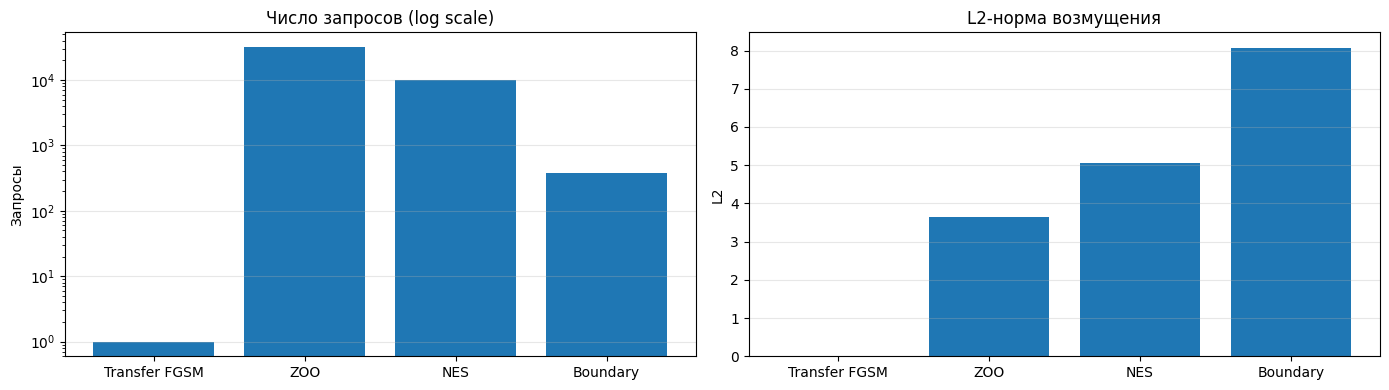

In [28]:
# TODO: постройте два столбчатых графика сравнения (число запросов — log-масштаб, L2-норма)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Число запросов в логарифмической шкале
axes[0].bar(summary['method'], summary['queries'])
axes[0].set_yscale('log')
axes[0].set_title('Число запросов (log scale)')
axes[0].set_ylabel('Запросы')
axes[0].grid(alpha=0.3, axis='y')

# L2-норма возмущения
axes[1].bar(summary['method'], summary['L2'])
axes[1].set_title('L2-норма возмущения')
axes[1].set_ylabel('L2')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

**Мой ответ**: 
**Полные вероятности без ограничения на запросы**. Лучший выбор — NES. Он использует вероятности для оценки градиента через случайные направления, обновляет все координаты за итерацию и тратит меньше запросов, чем ZOO, при сопоставимом качестве. ZOO тоже работает, но дороже. Если запросы бесплатны и время не жмёт, ZOO даст более аккуратное возмущение, но на практике NES выигрывает по совокупности.

**Только top-1 метка с жёстким лимитом запросов**. Остаётся только Boundary Attack. Он работает с дискретной меткой и не требует вероятностей. При жёстком лимите важно, что Boundary адаптивно подстраивает шаги и умеет останавливаться раньше. Другие методы тут вообще неприменимы: ZOO и NES требуют вероятностей, transfer-based требует данных для суррогата.

**Возможность собрать offline небольшой размеченный набор того же домена**. Формально это сценарий transfer-based: обучаем суррогат на данных, размеченных оракулом, атакуем его белоящично и переносим примеры на цель. Запросов к API при самой атаке почти не нужно, только финальная проверка. Именно этот подход описывает Papernot et al.

Однако в моем эксперименте transfer-based FGSM показал себя плохо. Суррогат обучался на данных, размеченных оракулом, но его градиенты оказались недостаточно похожи на градиенты цели. Согласие суррогата с оракулом было высокое, но не идеальное, а FGSM очень чувствителен к таким расхождениям: он делает всего один шаг и не может подстроиться. В итоге transfer ASR оказался низким, и атака обманула лишь малую часть примеров. transfer-based выигрывает по стоимости запросов, но в моей постановке он проиграл по качеству другим методам. Если бы суррогат был обучен лучше — например, с большим числом раундов или с архитектурой, близкой к целевой, — перенос мог бы сработать

Почему типы доступа определяют выбор: каждый метод использует ровно тот сигнал, который доступен. Transfer-based работает с данными, score-based с вероятностями, decision-based с метками. Чем меньше информации даёт API, тем изощрённее метод и тем больше запросов он потратит.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

**Мой ответ**: Три класса чёрно-ящичных атак используют разные уровни доступа и потому имеют разные профили.

**Transfer-based** работает через суррогат: обучаем свою модель на данных, размеченных оракулом, атакуем её белоящично, переносим примеры на цель. Трансферируемость объясняется кривизной многообразия данных. Реальные изображения лежат не во всём пространстве пикселей, а на низкоразмерном многообразии, где сосредоточены осмысленные картинки. Разные модели, обученные на похожих распределениях, учатся похожим границам решения вдоль этого многообразия, потому что структура данных диктует, где проходят разделяющие поверхности. Adversarial-примеры лежат рядом с этим многообразием, и одна модель может найти их для другой.

**Score-based** использует вероятности классов. Это даёт больше информации, чем метка, но требует много запросов. ZOO работает покоординатно, NES через случайные направления. NES эффективнее по запросам, потому что обновляет все координаты сразу.

**Decision-based** использует только метку. Это самый дешёвый по информации, но самый дорогой по запросам метод. Boundary Attack движется вдоль границы решения, постепенно уменьшая возмущение. Он работает в самых жёстких условиях.

**Adversarial training** через PGD снижает успех всех трёх классов атак, потому что сглаживает границу решения в окрестности реальных данных. Это сглаживание переносится на все методы: и transfer, и score-based, и decision-based сталкиваются с одной и той же сглаженной границей. Transfer проигрывает, потому что суррогат, обученный на чистых данных, плохо моделирует сглаженную цель. Score-based проигрывает, потому что градиенты в сглаженной области меньше по величине и хуже указывают направление. Decision-based проигрывает, потому что граница решения становится дальше от данных, и путь до неё длиннее.

Это показывает, что защита, разработанная против белоящичных атак, полезна и в чёрно-ящичном сценарии. Причина в том, что adversarial training меняет не отклик на конкретный вход, а саму геометрию решения: делает границу глаже и уводит её от данных. Это структурное изменение, и оно не зависит от того, каким способом атакующий пытается её найти. Именно поэтому PGD-adversarial training считается базовым методом защиты: он повышает устойчивость не к одной конкретной атаке, а к целому классу методов.



---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


**С2**  

**Importance sampling** — это идея выбирать координаты не равномерно, а с приоритетом тех, которые сильнее влияют на результат. В нашем случае есть несколько способов определить «важность» пикселя.

**Способ первый**: по значению пикселя. Пиксели с высокой яркостью (близкие к 1) часто находятся на самой цифре, а не на фоне. Если выбирать их чаще, атака быстрее сфокусируется на значимых областях.

**Способ второй**: по предыдущей оценке градиента. На предыдущей итерации мы оценивали производные для некоторых координат. Те пиксели, где оценка по модулю была большой, скорее всего важны и на следующей итерации. Их стоит выбирать снова с большей вероятностью.

**Способ третий**: по расстоянию до границы цифры. Пиксели на границе фигуры часто сильнее влияют на классификацию, чем пиксели внутри или снаружи.

При **temperature = 1** softmax работает как обычно. Пиксели со значением 1.0 получают вероятность примерно в 2.7 раза больше, чем пиксели со значением 0.0 (потому что softmax(1) / softmax(0) = e^1 / e^0 = e ≈ 2.7). Распределение получается довольно пологим: яркие пиксели чуть выигрывают, но и тёмные имеют шанс.

При **temperature = 0.5** делим на 0.5, то есть умножаем на 2. Значения пикселей становятся эффективно удвоенными. Пиксель со значением 1.0 получает вероятность примерно в e^2 ≈ 7.4 раза больше, чем пиксель со значением 0.0. Распределение становится более «острым»: яркие пиксели выигрывают сильно.

При **temperature = 0.1** умножаем на 10. Пиксель 1.0 получает вероятность в e^10 раз больше, чем пиксель 0.0 — это уже около 22000. Распределение почти полностью сконцентрировано на самых ярких пикселях, остальные получают пренебрежимо малый шанс.

При **temperature = 2.0** делим на 2, делим пиксели пополам. Отношение e^0.5 ≈ 1.65 — распределение сглаживается, приближается к равномерному.

**Способ первый**: по значению пикселя.

In [29]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
def zoo_attack_importance(oracle, x, y_true, epsilon=0.3, alpha=0.05,
                          num_iter=40, h=0.05, coord_batch=40,
                          importance_temperature=0.5):
    # Инициализация
    x_adv = x.clone().detach()
    eps = torch.full_like(x, epsilon)
    n_pixels = x[0].numel()

    for it in range(num_iter):
        # Берём значения пикселей текущего adversarial-примера
        # Форма [1, 1, 28, 28] → разворачиваем в вектор [784]
        pixel_values = x_adv.view(-1).abs()

        # Нормируем в вероятности через softmax с температурой.
        #превращаем значения пикселей в вероятности. Softmax даёт положительные числа, сумма которых равна 1.
        # Чем больше значение пикселя, тем выше его вероятность быть выбранным.
        # temperature < 1 обостряет распределение (концентрируемся на ярких),
        # temperature > 1 сглаживает (ближе к равномерному)
        weights = torch.softmax(pixel_values / importance_temperature, dim=0)

        # Взвешенный выбор coord_batch координат без возвращения
        coords = torch.multinomial(weights, coord_batch, replacement=False)

        # === Дальше всё как в обычной ZOO ===
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            idx = np.unravel_index(c.item(), x_adv[0].shape)
            x_plus = x_adv.clone()
            x_plus[(slice(None),) + idx] += h
            x_minus = x_adv.clone()
            x_minus[(slice(None),) + idx] -= h

            probs_plus = oracle.probs(x_plus)
            probs_minus = oracle.probs(x_minus)
            loss_plus = zoo_loss(probs_plus, y_true)
            loss_minus = zoo_loss(probs_minus, y_true)

            grad_est[(slice(None),) + idx] = (loss_plus - loss_minus) / (2 * h)

        with torch.no_grad():
            x_adv = x_adv - alpha * grad_est.sign()
            delta = torch.clamp(x_adv - x, -eps, eps)
            x_adv = torch.clamp(x + delta, 0, 1)

    return x_adv.detach()

ZOO (равномерная): success=True, L2=3.5573, queries=32000, time=47.52s
ZOO (importance):  success=True, L2=3.4248, queries=32000, time=45.95s
           method  success      L2  queries
0     ZOO uniform     True  3.5573    32000
1  ZOO importance     True  3.4248    32000


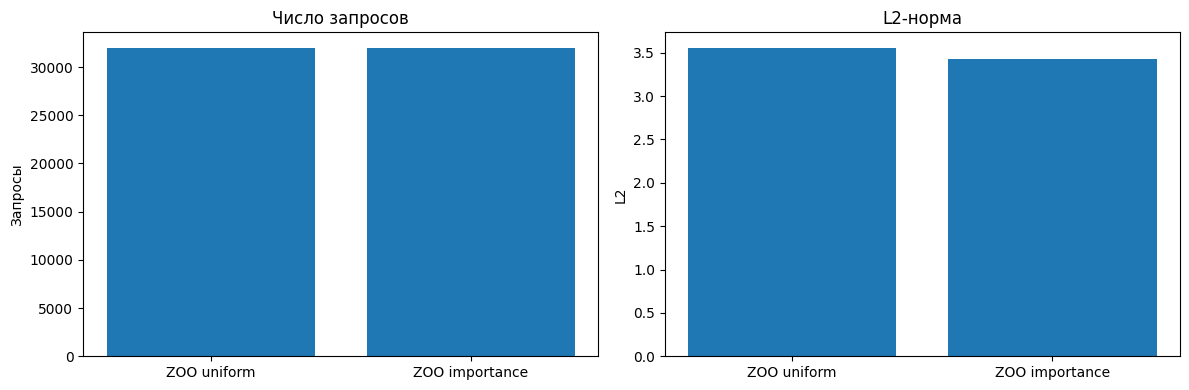

In [30]:
# Обычная ZOO
oracle.reset()
start = time.time()
x_adv_zoo_uniform = zoo_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                                num_iter=200, h=0.05, coord_batch=80)
time_uniform = time.time() - start
queries_uniform = oracle.n_queries
l2_uniform = (x_adv_zoo_uniform - x_sample).view(-1).norm(2).item()
pred_uniform = oracle.label(x_adv_zoo_uniform).item()
success_uniform = pred_uniform != pred_clean

print(f"ZOO (равномерная): success={success_uniform}, L2={l2_uniform:.4f}, "
      f"queries={queries_uniform}, time={time_uniform:.2f}s")

# ZOO с importance sampling
oracle.reset()
start = time.time()
x_adv_zoo_importance = zoo_attack_importance(oracle, x_sample, y_sample, epsilon=0.3,
                                              alpha=0.05, num_iter=200, h=0.05,
                                              coord_batch=80, importance_temperature=0.5)
time_importance = time.time() - start
queries_importance = oracle.n_queries
l2_importance = (x_adv_zoo_importance - x_sample).view(-1).norm(2).item()
pred_importance = oracle.label(x_adv_zoo_importance).item()
success_importance = pred_importance != pred_clean

print(f"ZOO (importance):  success={success_importance}, L2={l2_importance:.4f}, "
      f"queries={queries_importance}, time={time_importance:.2f}s")

# Таблица сравнения
comparison = pd.DataFrame([
    {'method': 'ZOO uniform',    'success': success_uniform,
     'L2': round(l2_uniform, 4),    'queries': queries_uniform},
    {'method': 'ZOO importance', 'success': success_importance,
     'L2': round(l2_importance, 4), 'queries': queries_importance},
])
print(comparison)

# График сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison['method'], comparison['queries'])
axes[0].set_title('Число запросов'); axes[0].set_ylabel('Запросы')
axes[1].bar(comparison['method'], comparison['L2'])
axes[1].set_title('L2-норма'); axes[1].set_ylabel('L2')
plt.tight_layout(); plt.show()

Importance sampling меняет не количество запросов за итерацию, а качество выбора координат. Вместо случайного разброса по всему изображению мы фокусируемся на пикселях с большими значениями, которые чаще всего принадлежат самой цифре, а не фону. Это должно ускорять сходимость: атака быстрее находит важные пиксели и меньше тратит итераций на бесполезные.

На практике выгода зависит от задачи. На MNIST, где цифра занимает центральную часть картинки, а фон чёрный, importance sampling по значению пикселя может дать заметный выигрыш: мы почти полностью игнорируем фон. На более сложных датасетах, где важные признаки распределены по всей картинке, выгода может быть меньше.  

importance sampling по значению пикселя — это эвристика, а не строгий статистический метод. Настоящий importance sampling в статистике требует нормировки весов и оценки дисперсии, чтобы гарантировать несмещённость. Мы используем упрощённый вариант, где просто смещаем распределение выбора в сторону «важных» пикселей. На практике это часто работает, но не всегда даёт выигрыш, и результат зависит от конкретной задачи и распределения данных.



**Способ второй**: по предыдущей оценке градиента.

In [31]:
def zoo_attack_grad_importance(oracle, x, y_true, epsilon=0.3, alpha=0.05,
                                num_iter=40, h=0.05, coord_batch=40,
                                history_decay=0.9, temperature=0.1):
    # Инициализация
    x_adv = x.clone().detach()
    eps = torch.full_like(x, epsilon)
    n_pixels = x[0].numel()

    # История оценок градиента по каждой координате.
    # Начинаем с нулей, но на первой итерации выбираем равномерно.
    grad_history = torch.zeros(n_pixels, device=x.device)

    for it in range(num_iter):
        # === Выбор координат по важности ===
        if it == 0:
            # Первая итерация: равномерный выбор, чтобы накопить информацию
            weights = torch.ones(n_pixels, device=x.device) / n_pixels
        else:
            # Вероятности пропорциональны |grad_history|
            # Добавляем маленькую константу, чтобы избежать нулевых вероятностей
            importance = grad_history.abs() + 1e-6

            # Нормируем в вероятности через softmax с температурой.
            # temperature маленькая — концентрируемся на важных координатах,
            # temperature большая — приближаемся к равномерному выбору
            weights = torch.softmax(importance / temperature, dim=0)

        # Взвешенный выбор без возвращения
        coords = torch.multinomial(weights, coord_batch, replacement=False)

        # === Оценка градиента для выбранных координат ===
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            idx = np.unravel_index(c.item(), x_adv[0].shape)
            x_plus = x_adv.clone()
            x_plus[(slice(None),) + idx] += h
            x_minus = x_adv.clone()
            x_minus[(slice(None),) + idx] -= h

            probs_plus = oracle.probs(x_plus)
            probs_minus = oracle.probs(x_minus)
            loss_plus = zoo_loss(probs_plus, y_true)
            loss_minus = zoo_loss(probs_minus, y_true)

            # Центральная разность
            grad_value = (loss_plus - loss_minus) / (2 * h)
            grad_est[(slice(None),) + idx] = grad_value

            # Обновляем историю для этой координаты.
            # Затухание позволяет старым оценкам постепенно забываться.
            grad_history[c.item()] = (history_decay * grad_history[c.item()]
                                       + (1 - history_decay) * grad_value.abs())

        # === Шаг атаки ===
        with torch.no_grad():
            x_adv = x_adv - alpha * grad_est.sign()
            delta = torch.clamp(x_adv - x, -eps, eps)
            x_adv = torch.clamp(x + delta, 0, 1)

    return x_adv.detach()

Uniform:    success=True, L2=3.4801, queries=32000, time=55.98s
Pixel-imp:  success=True, L2=3.3925, queries=32000, time=52.19s
Grad-imp:   success=True, L2=3.3352, queries=32000, time=46.75s
      method  success      L2  queries
0    Uniform     True  3.4801    32000
1  Pixel-imp     True  3.3925    32000
2   Grad-imp     True  3.3352    32000


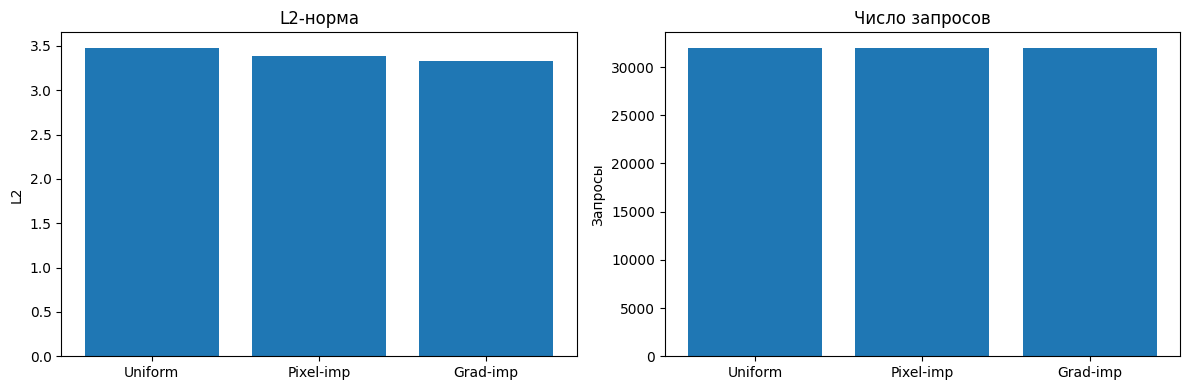

In [32]:
# Равномерная
oracle.reset()
start = time.time()
x_adv_uniform = zoo_attack(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                            num_iter=200, h=0.05, coord_batch=80)
time_uniform = time.time() - start
queries_uniform = oracle.n_queries
l2_uniform = (x_adv_uniform - x_sample).view(-1).norm(2).item()
success_uniform = oracle.label(x_adv_uniform).item() != pred_clean

print(f"Uniform:    success={success_uniform}, L2={l2_uniform:.4f}, "
      f"queries={queries_uniform}, time={time_uniform:.2f}s")

# По значению пикселя
oracle.reset()
start = time.time()
x_adv_pixel = zoo_attack_importance(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                                     num_iter=200, h=0.05, coord_batch=80,
                                     importance_temperature=0.5)
time_pixel = time.time() - start
queries_pixel = oracle.n_queries
l2_pixel = (x_adv_pixel - x_sample).view(-1).norm(2).item()
success_pixel = oracle.label(x_adv_pixel).item() != pred_clean

print(f"Pixel-imp:  success={success_pixel}, L2={l2_pixel:.4f}, "
      f"queries={queries_pixel}, time={time_pixel:.2f}s")

# По оценке градиента
oracle.reset()
start = time.time()
x_adv_grad = zoo_attack_grad_importance(oracle, x_sample, y_sample, epsilon=0.3, alpha=0.05,
                                         num_iter=200, h=0.05, coord_batch=80,
                                         history_decay=0.9, temperature=0.1)
time_grad = time.time() - start
queries_grad = oracle.n_queries
l2_grad = (x_adv_grad - x_sample).view(-1).norm(2).item()
success_grad = oracle.label(x_adv_grad).item() != pred_clean

print(f"Grad-imp:   success={success_grad}, L2={l2_grad:.4f}, "
      f"queries={queries_grad}, time={time_grad:.2f}s")

# Сводная таблица
comparison = pd.DataFrame([
    {'method': 'Uniform',        'success': success_uniform, 'L2': round(l2_uniform, 4), 'queries': queries_uniform},
    {'method': 'Pixel-imp',      'success': success_pixel,   'L2': round(l2_pixel, 4),   'queries': queries_pixel},
    {'method': 'Grad-imp',       'success': success_grad,    'L2': round(l2_grad, 4),    'queries': queries_grad},
])
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison['method'], comparison['L2'])
axes[0].set_title('L2-норма'); axes[0].set_ylabel('L2')
axes[1].bar(comparison['method'], comparison['queries'])
axes[1].set_title('Число запросов'); axes[1].set_ylabel('Запросы')
plt.tight_layout(); plt.show()

Версия по градиенту лучше версии по значению пикселя. Пиксели, которые действительно влияют на лосс, важнее пикселей, которые просто яркие. Яркий фон или край цифры могут быть яркими, но не влиять на решение, а градиент показывает реальное влияние.

**С4**

In [35]:
def pgd_attack_train(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    model.eval()  # важно: во время генерации атаки BN/dropout выключены

    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)

    x_adv = torch.clamp(x + delta, 0.0, 1.0)

    for _ in range(num_iter):
        x_adv = x_adv.detach().requires_grad_(True)
        logits = model(x_adv)
        loss = criterion(logits, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            delta = x_adv - x + alpha * x_adv.grad.sign()
            delta = torch.clamp(delta, -epsilon, epsilon)
            x_adv = torch.clamp(x + delta, 0.0, 1.0)

    return x_adv.detach()

In [ ]:
import copy
import time

adv_model = TargetCNN().to(device)
assert adv_model is not target_model, "adv_model должен быть НОВОЙ моделью"

adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

EPS_TRAIN   = 0.15
ALPHA_TRAIN = 0.0375   # = eps/4, размер шага PGD
NUM_ITER_TRAIN = 5     # как просили — 5 итераций
N_EPOCHS_ADV = 4

def train_epoch_adv(model, loader, optimizer, criterion, device,
                    epsilon, alpha, num_iter):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # 1) внутренний максимум: PGD-пример
        x_adv = pgd_attack_train(model, x, y, epsilon, alpha, num_iter, criterion,
                                  randomize=True)

        # 2) внешний шаг: обновляем веса на adversarial-примерах
        optimizer.zero_grad()
        logits = model(x_adv)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)

    return total_loss / total, correct / total


def evaluate_accuracy_with_adv(model, loader, device,
                               epsilon=0.15, alpha=0.0375, num_iter=5):
    model.eval()
    correct_clean, correct_adv, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            correct_clean += (model(x).argmax(1) == y).sum().item()
        x_adv = pgd_attack_train(model, x, y, epsilon, alpha, num_iter,
                                  criterion, randomize=False)
        with torch.no_grad():
            correct_adv += (model(x_adv).argmax(1) == y).sum().item()
        total += x.size(0)
    return correct_clean / total, correct_adv / total

In [38]:
print("=== Adversarial training (PGD, 5 итераций, eps=0.15) ===")
adv_history = []
t_start = time.time()

for epoch in range(N_EPOCHS_ADV):
    t0 = time.time()
    loss, acc_adv_train = train_epoch_adv(
        adv_model, train_loader, adv_optimizer, criterion, device,
        EPS_TRAIN, ALPHA_TRAIN, NUM_ITER_TRAIN
    )
    t_epoch = time.time() - t0

    # Раз в эпоху — честная оценка clean + robust на части теста
    clean_acc, robust_acc = evaluate_accuracy_with_adv(
        adv_model, test_loader, device,
        EPS_TRAIN, ALPHA_TRAIN, NUM_ITER_TRAIN
    )
    adv_history.append({
        'epoch': epoch + 1,
        'train_loss': round(loss, 4),
        'train_acc_adv': round(acc_adv_train, 4),
        'clean_acc': round(clean_acc, 4),
        'robust_acc': round(robust_acc, 4),
        'time_s': round(t_epoch, 1),
    })
    print(f"Эпоха {epoch+1}/{N_EPOCHS_ADV}: "
          f"loss={loss:.4f}, train_acc_adv={acc_adv_train:.4f}, "
          f"clean={clean_acc:.4f}, robust={robust_acc:.4f}, "
          f"time={t_epoch:.1f}s")

print(f"\nИтого: {time.time()-t_start:.1f}s")

=== Adversarial training (PGD, 5 итераций, eps=0.15) ===
Эпоха 1/4: loss=0.9740, train_acc_adv=0.6775, clean=0.9605, robust=0.8344, time=538.6s
Эпоха 2/4: loss=0.4205, train_acc_adv=0.8633, clean=0.9746, robust=0.8759, time=630.4s
Эпоха 3/4: loss=0.3396, train_acc_adv=0.8887, clean=0.9780, robust=0.8894, time=602.8s
Эпоха 4/4: loss=0.2981, train_acc_adv=0.9021, clean=0.9826, robust=0.9017, time=610.9s

Итого: 2766.9s


In [39]:
clean_acc_normal = evaluate_accuracy(target_model, test_loader, device)
clean_acc_adv_model = evaluate_accuracy(adv_model, test_loader, device)
print(f"Clean accuracy обычной модели:      {clean_acc_normal:.4f}")
print(f"Clean accuracy adversarial-модели:  {clean_acc_adv_model:.4f}")

Clean accuracy обычной модели:      0.9879
Clean accuracy adversarial-модели:  0.9826


In [40]:
adv_oracle = QueryCounter(adv_model)

x_eval = x_sample.clone()
y_eval = y_sample.clone()

# clean-предсказание считаем отдельно для каждой модели
oracle.reset()
pred_clean_normal = oracle.label(x_eval).item()
adv_oracle.reset()
pred_clean_adv = adv_oracle.label(x_eval).item()
print(f"Clean-предсказание обычной модели: {pred_clean_normal}")
print(f"Clean-предсказание adv-модели:     {pred_clean_adv}")

results = []

# ---------- Обычная модель ----------
for name, oracle_cur, pred_clean_cur in [
    ("обычная", oracle, pred_clean_normal),
    ("adv-PGD", adv_oracle, pred_clean_adv),
]:
    # ZOO
    oracle_cur.reset()
    t0 = time.time()
    x_zoo = zoo_attack(oracle_cur, x_eval, y_eval, epsilon=0.3, alpha=0.05,
                       num_iter=200, h=0.05, coord_batch=80)
    t_zoo = time.time() - t0
    q_zoo = oracle_cur.n_queries
    pred_zoo = oracle_cur.label(x_zoo).item()
    l2_zoo = (x_zoo - x_eval).view(-1).norm(2).item()

    # NES
    oracle_cur.reset()
    t0 = time.time()
    x_nes = nes_attack(oracle_cur, x_eval, y_eval, epsilon=0.3, alpha=0.02,
                       num_iter=250, sigma=0.1, n_samples=20)
    t_nes = time.time() - t0
    q_nes = oracle_cur.n_queries
    pred_nes = oracle_cur.label(x_nes).item()
    l2_nes = (x_nes - x_eval).view(-1).norm(2).item()

    # Boundary Attack
    # Ищем стартовую точку, которая уже adversarial для этого оракула
    oracle_cur.reset()
    x_init = torch.rand_like(x_eval)
    attempts = 0
    while not is_adversarial(oracle_cur, x_init, y_eval.item()):
        x_init = torch.rand_like(x_eval)
        attempts += 1
        if attempts > 200:
            break
    t0 = time.time()
    x_bnd, _ = boundary_attack(oracle_cur, x_eval, y_eval.item(), x_init,
                               num_steps=200, init_delta=0.05, init_epsilon=0.05)
    t_bnd = time.time() - t0
    q_bnd = oracle_cur.n_queries
    pred_bnd = oracle_cur.label(x_bnd).item()
    l2_bnd = (x_bnd - x_eval).view(-1).norm(2).item()

    # Записываем результаты
    results.append({'model': name, 'attack': 'ZOO',
                    'success': pred_zoo != pred_clean_cur,
                    'L2': round(l2_zoo, 4), 'queries': q_zoo,
                    'time_s': round(t_zoo, 2)})
    results.append({'model': name, 'attack': 'NES',
                    'success': pred_nes != pred_clean_cur,
                    'L2': round(l2_nes, 4), 'queries': q_nes,
                    'time_s': round(t_nes, 2)})
    results.append({'model': name, 'attack': 'Boundary',
                    'success': pred_bnd != pred_clean_cur,
                    'L2': round(l2_bnd, 4), 'queries': q_bnd,
                    'time_s': round(t_bnd, 2)})

# Сводная таблица
df_c4 = pd.DataFrame(results)
print()
print(df_c4)

# Краткая интерпретация
print("\nСнижение ASR при переходе к защищённой модели:")
for attack in ['ZOO', 'NES', 'Boundary']:
    s_normal = df_c4[(df_c4.model == 'обычная') & (df_c4.attack == attack)]['success'].iloc[0]
    s_adv = df_c4[(df_c4.model == 'adv-PGD') & (df_c4.attack == attack)]['success'].iloc[0]
    print(f"  {attack:8s}: обычная={s_normal}, adv-PGD={s_adv}")

Clean-предсказание обычной модели: 7
Clean-предсказание adv-модели:     7

     model    attack  success      L2  queries  time_s
0  обычная       ZOO     True  3.6430    32000   56.17
1  обычная       NES     True  5.2035    10000   14.48
2  обычная  Boundary     True  9.7639      379    0.50
3  adv-PGD       ZOO     True  5.1985    32000   48.59
4  adv-PGD       NES    False  5.4493    10000   14.02
5  adv-PGD  Boundary     True  8.1589      398    0.47

Снижение ASR при переходе к защищённой модели:
  ZOO     : обычная=True, adv-PGD=True
  NES     : обычная=True, adv-PGD=False
  Boundary: обычная=True, adv-PGD=True


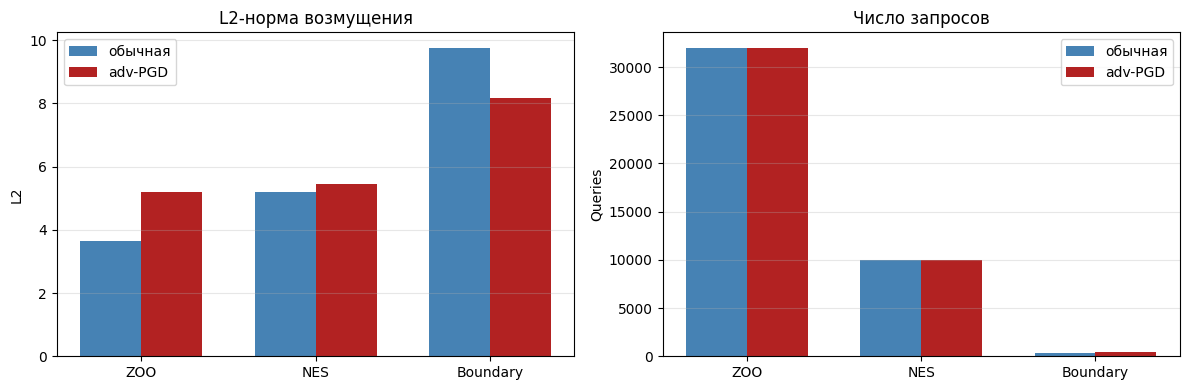

In [45]:
attacks = ['ZOO', 'NES', 'Boundary']

def get_val(model_name, attack, col):
    return df_c4[(df_c4.model == model_name) & (df_c4.attack == attack)][col].iloc[0]

l2_normal  = [get_val('обычная', a, 'L2') for a in attacks]
l2_adv     = [get_val('adv-PGD', a, 'L2') for a in attacks]
q_normal   = [get_val('обычная', a, 'queries') for a in attacks]
q_adv      = [get_val('adv-PGD', a, 'queries') for a in attacks]

x_pos = np.arange(len(attacks))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x_pos - w/2, l2_normal, w, label='обычная', color='steelblue')
axes[0].bar(x_pos + w/2, l2_adv,    w, label='adv-PGD', color='firebrick')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(attacks)
axes[0].set_ylabel('L2'); axes[0].set_title('L2-норма возмущения')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x_pos - w/2, q_normal, w, label='обычная', color='steelblue')
axes[1].bar(x_pos + w/2, q_adv,    w, label='adv-PGD', color='firebrick')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(attacks)
axes[1].set_ylabel('Queries'); axes[1].set_title('Число запросов')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

NES против защищённой модели не сработал вообще — это прямой перенос
устойчивости от PGD. NES и PGD используют один и тот же сигнал: градиент
лосса. Adversarial training сгладил границу решения и сделал градиенты
менее информативными, поэтому NES за те же 10000 запросов не смог найти
adversarial-пример.

ZOO сохранил успех, но L2-норма выросла с 3.64 до 5.20 — атаке пришлось
уйти дальше от оригинала, чтобы обмануть модель. Это тоже проявление
защиты: тот же успех достигнут за счёт большего возмущения.

Boundary Attack сохранил успех, потому что работает только с метками,
без градиентов. Сглаживание границы его не ломает — он ищет её вслепую.
L2 при этом даже немного снизился, что может быть случайностью одного
примера.

Устойчивость от white-box PGD переносится на score-based атаки
(NES явно, ZOO частично — через рост L2), но почти не переносится на
decision-based Boundary Attack. Adversarial training меняет геометрию
границы решения, а не подгоняет модель под конкретную атаку, поэтому
защита работает против методов, использующих градиент, но не против
тех, что ищут границу вслепую.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
